Importamos las librerias necesarias para manipulación y visualización de datos, despues importamos el dataset usando pandas para leer el archivo .csv

In [115]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [116]:
df = pd.read_csv('../Anexos/DatosSeguros.csv')
df.head(5)

,edad,sexo,imc,hijos,fumador,region,valor_seguro
0,19,F,27.90,0,yes,Caribe,16884.9240
1,19,F,27.90,0,yes,Caribe,16884.9240
2,19,F,27.90,0,yes,Caribe,16884.9240
3,18,M,33.77,1,no,Cundinamarca,1725.5523
4,28,M,33.00,3,no,Cundinamarca,4449.4620


Antes de continuar procedemos a hacer limpieza de datos buscando datos nulos y duplicados que afectarian los resultados finales

In [117]:
df.isnull().sum()

edad            0
sexo            0
imc             2
hijos           0
fumador         2
region          0
valor_seguro    0
dtype: int64

Tenemos 2 variables con valores nulos, determine que no afectaran directamente el resultado final ya que no son demasiados datos afectados

In [118]:
df.duplicated().sum()

np.int64(12)

Ya que no son muchos valores duplicados, revisamos cuales son

In [119]:
filas_duplicadas = df.value_counts(dropna=False).reset_index(name='frecuencia')
filas_duplicadas = filas_duplicadas[filas_duplicadas['frecuencia'] > 1]
filas_duplicadas.head(10)

,edad,sexo,imc,hijos,fumador,region,valor_seguro,frecuencia
0,19,F,27.900,0,yes,Caribe,16884.92400,7
1,38,M,16.815,2,no,Boyaca,6640.54485,4
2,19,M,30.590,0,no,Antioquia,1639.56310,2
3,52,M,34.485,3,yes,Antioquia,60021.39897,2
4,20,F,21.800,0,yes,Caribe,20167.33603,2


Podemos observar que 5 datos estan duplicados multiples veces dentro del dataset.

#### Crear un nuevo dataset
Hacemos una copia limpia del dataset como buena practica para no manipular el data set original eliminando nulos y duplicados

In [120]:
df_clean = df.dropna().drop_duplicates().copy()
df_clean.info()

<class 'pandas.DataFrame'>
Index: 1333 entries, 0 to 1347
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   edad          1333 non-null   int64  
 1   sexo          1333 non-null   str    
 2   imc           1333 non-null   float64
 3   hijos         1333 non-null   int64  
 4   fumador       1333 non-null   str    
 5   region        1333 non-null   str    
 6   valor_seguro  1333 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 83.3 KB


Vamos a separar por rango los datos para reducir el ruido y darle manejo a cualquier dato atipico que pueda tener, para esto haremos un rango por edades, usando .describe podemos hcer un resumen estadistico sencillo y tambien podemos observar cuales son las edades minimas y maximas del dataset

In [121]:
df_clean.describe()


,edad,imc,hijos,valor_seguro
count,1333.000000,1333.000000,1333.000000,1333.000000
mean,39.195049,30.652097,1.092273,13261.908454
std,14.052008,6.097609,1.205484,12093.507648
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.220000,0.000000,4738.268200
50%,39.000000,30.360000,1.000000,9377.904700
75%,51.000000,34.675000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [122]:
rangos = [17, 25, 35, 45, 55, 65]
nombre_rangos = ['18-24', '25-34', '35-44', '45-54', '55+']

# Nueva variable
df_clean['rango_edad'] = pd.cut(df_clean['edad'], bins=rangos, labels=nombre_rangos)
df_clean.head(5)

,edad,sexo,imc,hijos,fumador,region,valor_seguro,rango_edad
0,19,F,27.900,0,yes,Caribe,16884.92400,18-24
3,18,M,33.770,1,no,Cundinamarca,1725.55230,18-24
4,28,M,33.000,3,no,Cundinamarca,4449.46200,25-34
5,33,M,22.705,0,no,Antioquia,21984.47061,25-34
6,32,M,28.880,0,no,Antioquia,3866.85520,25-34


### Análisis Estadístico y Visualización de Datos

Vamos a responder las preguntas iniciales
### 1. ¿Las personas fumadoras representan el mayor potencial para venta de seguros?

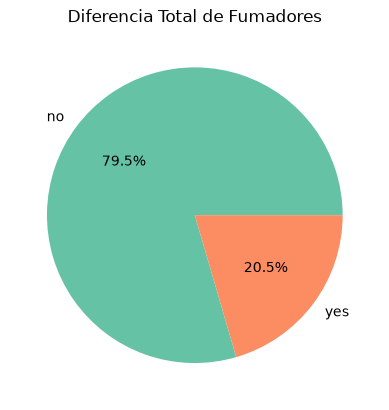

In [123]:
# Diferencia entre fumadores y no fumadores
total_fumador = df_clean['fumador'].value_counts() * 100
labels = df_clean['fumador'].value_counts().index
colors = sns.color_palette('Set2')[0:2]

plt.title('Diferencia Total de Fumadores')
plt.pie(total_fumador, labels=labels, colors=colors, autopct='%1.1f%%')
plt.show()

fumador
no     $8,942,511.57
yes    $8,735,612.40
Name: valor_seguro, dtype: str


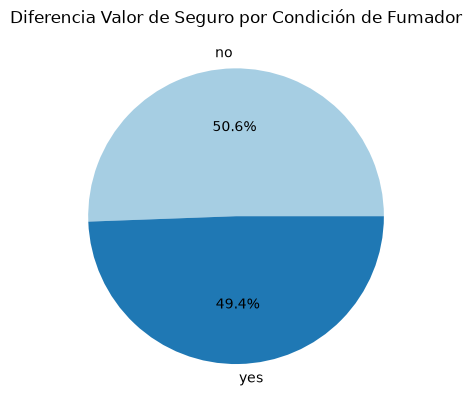

In [124]:
# Diferencia en el valor de seguro entre fumadores y no fumadores
res_valor_seguro = df_clean['valor_seguro'].groupby(df_clean['fumador']).sum()
labels = df_clean['fumador'].value_counts().index
colors = sns.color_palette('Paired')[0:2]

print(f"{res_valor_seguro.map("${:,.2f}".format)}")

plt.title('Diferencia Valor de Seguro por Condición de Fumador')
plt.pie(res_valor_seguro, labels=labels, colors=colors, autopct='%1.1f%%')
plt.show()

fumador  count       mean     median           sum
     no   1060  $8,436.33  $7,345.41 $8,942,511.57
    yes    273 $31,998.58 $34,439.86 $8,735,612.40


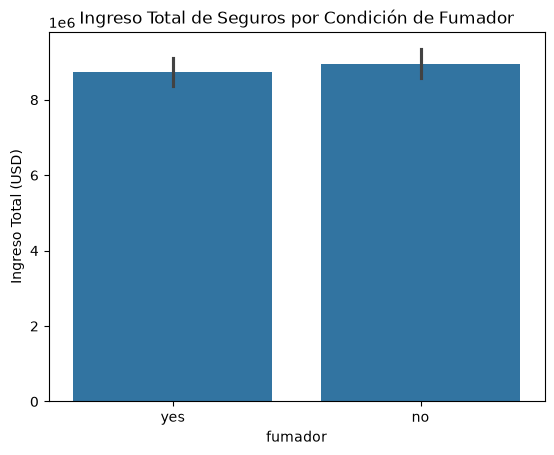

In [125]:
# Agrupamiento descripcion por condicion de fumador
res_fumador = (
    df_clean.groupby('fumador')['valor_seguro']
    .agg(['count', 'mean', 'median', 'sum'])
    .reset_index()
)

formatos = {"mean": "${:,.2f}".format, "median": "${:,.2f}".format, "sum": "${:,.2f}".format}
print(res_fumador.to_string(formatters=formatos, index=False))

# Grafico Barplot
sns.barplot(
    data=df_clean, x='fumador', y='valor_seguro', estimator=sum
)
plt.title('Ingreso Total de Seguros por Condición de Fumador')
plt.ylabel('Ingreso Total (USD)')
plt.show()

#### Respuesta

Si, en términos de valor individual e ingreso por cliente, pero se debe considerar el volumen poblacional

##### Fumadores
- Si fumadores: Representan el 20.5% de la poblacion (273 personas), estos generan casi la mitad de los ingresos totales ($8,735,612 USD / 49.35%)
- No fumadores: Son el 79.5% de los clientes (1062 personas) y generan un 50.6% ($8,965,156)

##### Conclusion
Las personas fumadoras representan el ingreso promedio mas alto. Sin embargo, comercialmente la estrategia ideal es mixta: captar fumadores para alta rentabilidad por cliente y no fumadores para asegurar volumen e ingresos sostenidos a un bajo nivel de riesgo.

### 2. ¿Cual es la edad poblacional en la que se debe concentrar la estrategia comercial teniendo en cuenta el mayor ingreso?

rango_edad
18-24    $2,778,987.27
25-34    $2,812,703.70
35-44    $3,555,014.40
45-54    $4,484,412.72
55+      $4,047,005.87
Name: valor_seguro, dtype: str


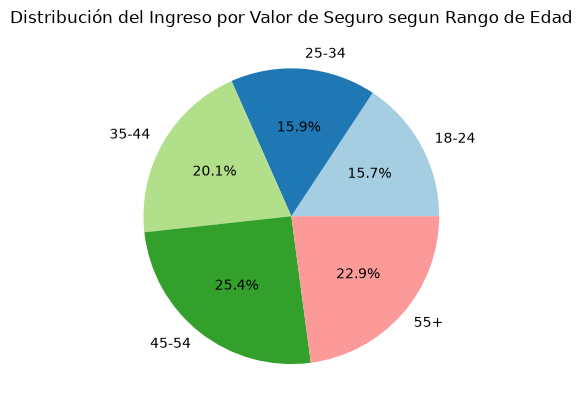

In [126]:
# Agrupamiento por rango de edad
res_rango_edad = df_clean.groupby('rango_edad')['valor_seguro'].sum()
labels = res_rango_edad.index
colors = sns.color_palette('Paired')[0:len(labels)]

print(f"{res_rango_edad.map("${:,.2f}".format)}")

# Gráfico Ingreso por Valor de Seguro según Rango de Edad
plt.title('Distribución del Ingreso por Valor de Seguro segun Rango de Edad')
plt.pie(res_rango_edad, labels=labels, colors=colors, autopct='%1.1f%%')
plt.show()

rango_edad  count       mean           sum
     18-24    305  $9,111.43 $2,778,987.27
     25-34    268 $10,495.16 $2,812,703.70
     35-44    263 $13,517.17 $3,555,014.40
     45-54    282 $15,902.17 $4,484,412.72
       55+    215 $18,823.28 $4,047,005.87


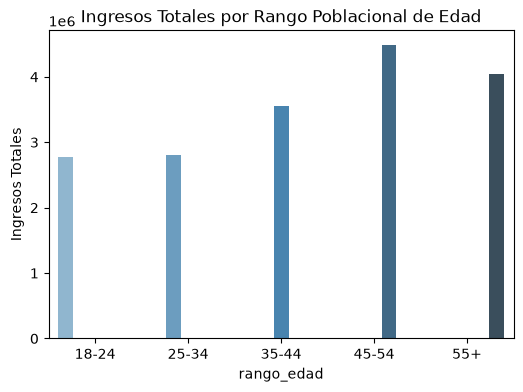

In [127]:
# Agrupamiento por rango de edad
res_edad = (
    df_clean.groupby('rango_edad')['valor_seguro']
    .agg(['count', 'mean', 'sum'])
    .reset_index()
)
formatos = {"mean": "${:,.2f}".format, "sum": "${:,.2f}".format}
print(res_edad.to_string(formatters=formatos, index=False))

# Gráfico de Barras por Rango de Edad
plt.figure(figsize=(6, 4))
sns.barplot(
    data=res_edad,
    x='rango_edad',
    y='sum',
    palette='Blues_d',
    hue='rango_edad',
    legend=False,
)
plt.title('Ingresos Totales por Rango Poblacional de Edad')
plt.ylabel('Ingresos Totales')
plt.show()

#### Respuesta
La estrategia comercial debe concentrarse en el rango de 45 a 54 años (seguido muy de cerca por el rango de 55+ años)

- Rango 45-54 años: Es el líder en generación de ingresos con $4,484,412.72 (25.4% del ingreso total del negocio)
- Rango 55+ años: Genera $4,047,005.87 (22.9% del ingreso total) con el promedio unitario más alto de todos los grupos ($18,513.28)

##### Conclusion
Los grupos mayores de 45 años representan casi el 50% del ingreso total. Las personas mas jovenes generan un promedio mucho mas bajo, por lo que enfocar presupuesto comercial en adultos de 45 a 54 años maximizara el retorno del valor recaudado por seguro

### 3. ¿Cuál es la región con mayor potencial de venta de seguros teniendo en cuenta los ingresos?

      region  count       mean           sum
   Antioquia    323 $12,466.89 $4,026,806.73
      Boyaca    323 $13,417.81 $4,333,952.74
      Caribe    325 $12,346.94 $4,012,754.65
Cundinamarca    362 $14,653.62 $5,304,609.85


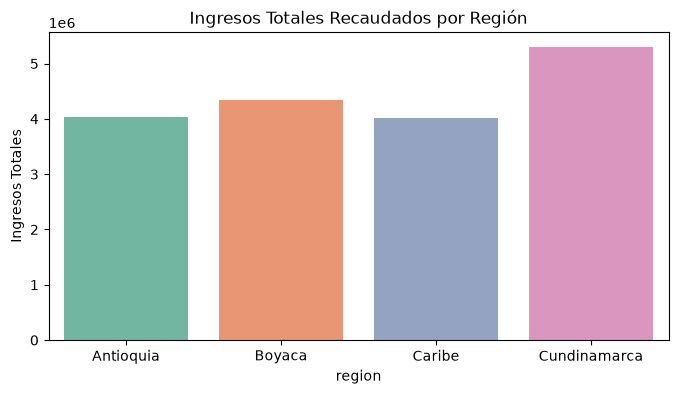

In [128]:
# Agrupamiento por region
res_region = (
    df_clean.groupby('region')['valor_seguro']
    .agg(['count', 'mean', 'sum'])
    .reset_index()
)

formatos = {"mean": "${:,.2f}".format, "sum": "${:,.2f}".format}
print(res_region.to_string(formatters=formatos, index=False))

# Gráfico de Ingresos por Region
plt.figure(figsize=(8, 4))
sns.barplot(
    data=res_region,
    x='region',
    y='sum',
    palette='Set2',
    hue='region',
    legend=False,
)
plt.title('Ingresos Totales Recaudados por Región')
plt.ylabel('Ingresos Totales')
plt.show()

#### Respuesta
La region con mayor potencial de venta es Cundinamarca

- Cundinamarca: Ocupa el primer lugar absoluto en ingresos con $5,304,609.85 (representa el 30.01% de las ventas totales). Además, cuenta con el mayor número de clientes registrados (362) y el promedio de recargo/seguro más alto ($14,653.62).
- Comparativa: Boyacá ocupa el segundo lugar con $4,333,952.74 (24.51%), Antioquia el tercero con $4,026,806.73 (22.78%), y el Caribe el cuarto con $4,012,754.65 (22.7%)

##### Conclusion
Cundinamarca combina la mayor concentración de clientes con las primas promedio más elevadas, consolidándose como la región estratégica prioritaria